# Analyze grid search results

In [1]:
%matplotlib ipympl

import pickle
import numpy as np
import jax
import jax.numpy as jnp
import os
import matplotlib.pyplot as plt
import matplotlib.image as mp_img

jax.config.update("jax_enable_x64", True)
jnp.set_printoptions(linewidth=2**20)

In [2]:
dir_name = "/Users/jozbee/work/eng/comp/scripts/grid_data"
files = os.listdir(dir_name)
pickle_files = [f for f in files if ".pickle" in f]

data = []
for pickle_name in pickle_files:
    with open(f"{dir_name}/{pickle_name}", "rb") as f:
        data.append(pickle.load(f))
        data[-1]["name"] = pickle_name.split("_")[0]  # grab number
    
sdata = sorted(data, key=lambda d: d["tot_err"])

In [3]:
def pprint(d: dict) -> None:
    for key, val in d.items():
        print(f'{key}: {str(val).replace("\n", " ")}')

In [4]:
plt.close("all")

weights: ExpWeights(acc=Array([5., 5., 1.], dtype=float64), omega=Array([1., 1., 5.], dtype=float64), leg=Array([1., 1., 1., 1., 1., 1.], dtype=float32), leg_vel=Array([1., 1., 1., 1., 1., 1.], dtype=float32), joint_angle=Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32), yaw=Array([1.], dtype=float32), control=Array([1., 1., 1., 1., 1., 1.], dtype=float32), alpha_acc=Array([1.], dtype=float64), alpha_omega=Array([4.], dtype=float64), alpha_leg=Array([0.], dtype=float32), alpha_leg_vel=Array([0.], dtype=float32), alpha_joint_angle=Array([0.], dtype=float32), alpha_yaw=Array([0.], dtype=float32), alpha_control=Array([0.], dtype=float32))
cost_terms: CostTerms(leg_cost=QuarticCost(coeffs=Array([[3.90625000e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],        [7.71604938e+01, 0.00000000e+00, 3.75000000e+01, 1.00000000e+01, 1.00000000e+00],        [7.91666667e+03, 0.00000000e+00, 7.91666667e+01, 4.08333333e+01, 8.00000000e+00],        [9.3962500

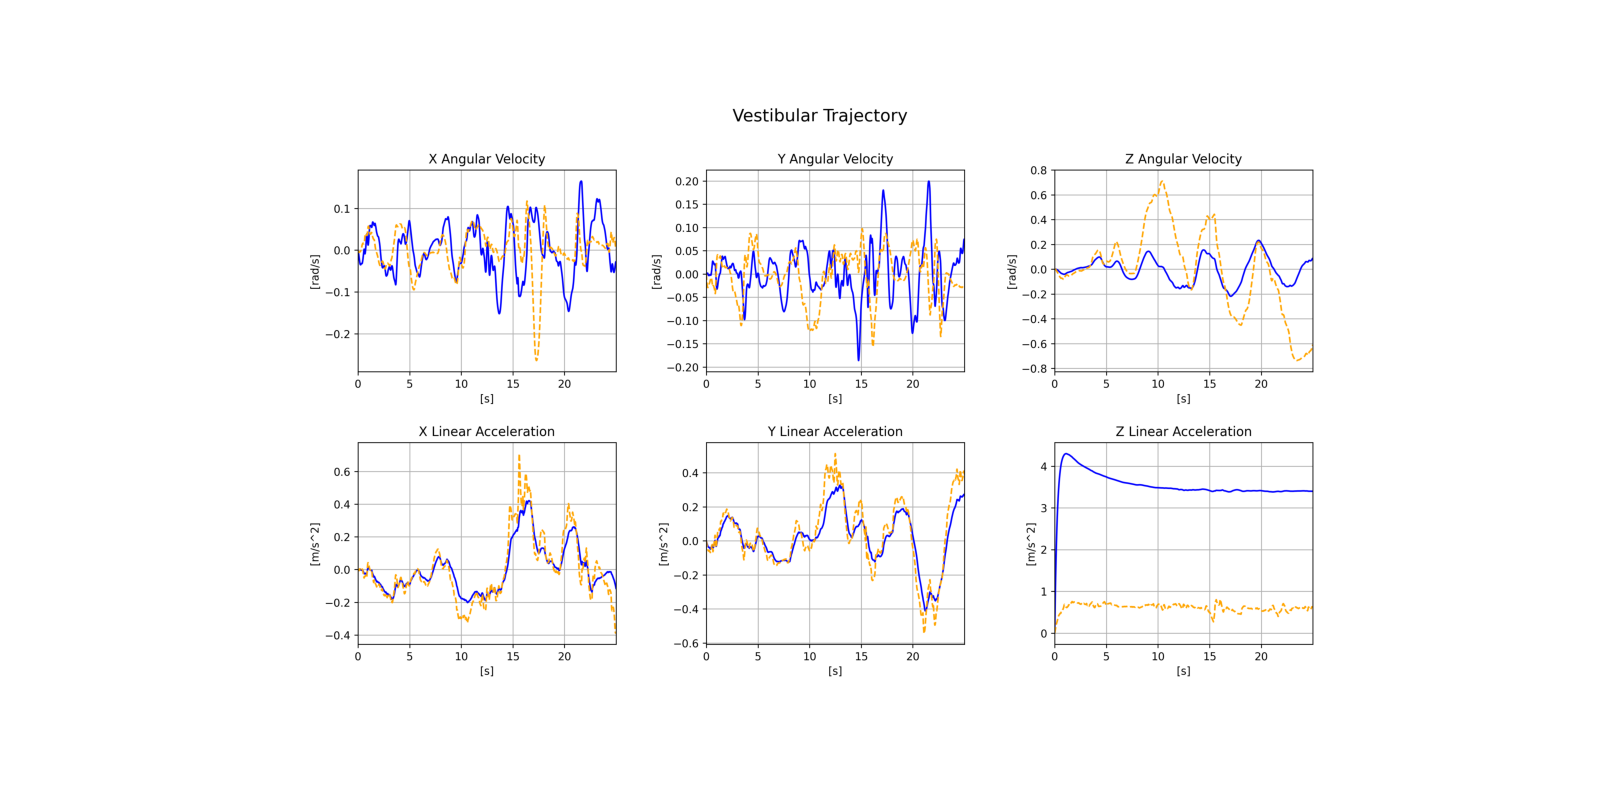

In [23]:
# idx = 14
idx = 14
pprint(sdata[idx])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))
img = mp_img.imread(f"{dir_name}/{sdata[idx]["name"]}_vestibular.png")
ax.imshow(img)
ax.axis("off")
plt.show()